In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

print("TensorFlow:", tf.__version__)
print("Setup ready ✅")

TensorFlow: 2.21.0
Setup ready ✅


TensorFlow Version: 2.21.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Dataset Loaded Successfully!
Training images: (60000, 28, 28)
Testing images : (10000, 28, 28)


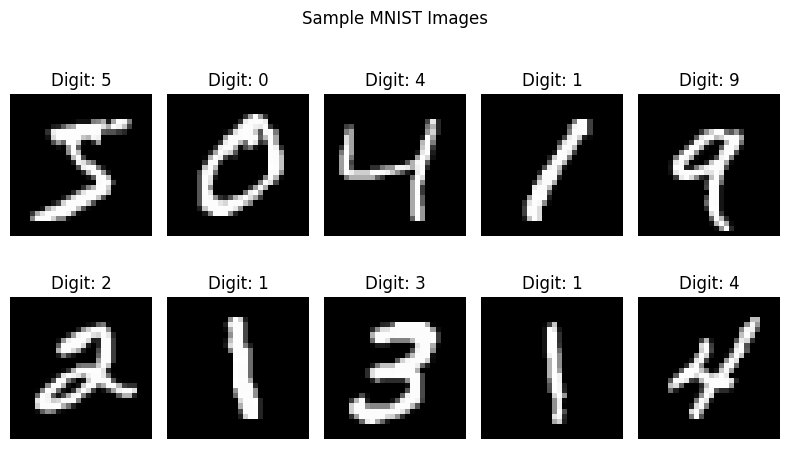


CNN Model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 65s 149ms/step - accuracy: 0.9224 - loss: 0.2598 - val_accuracy: 0.9810 - val_loss: 0.0657
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.9759 - loss: 0.0783 - val_accuracy: 0.9872 - val_loss: 0.0447
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 75s 90ms/step - accuracy: 0.9828 - loss: 0.0554 - val_accuracy: 0.9860 - val_loss: 0.0508
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9860 - loss: 0.0454 - val_accuracy: 0.9892 - val_loss: 0.0360
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9884 - loss: 0.0373 - val_accuracy: 0.9900 - val_loss: 0.0331

FINAL RESULTS
Test Loss     : 0.0308
Test Accuracy : 98.92 %


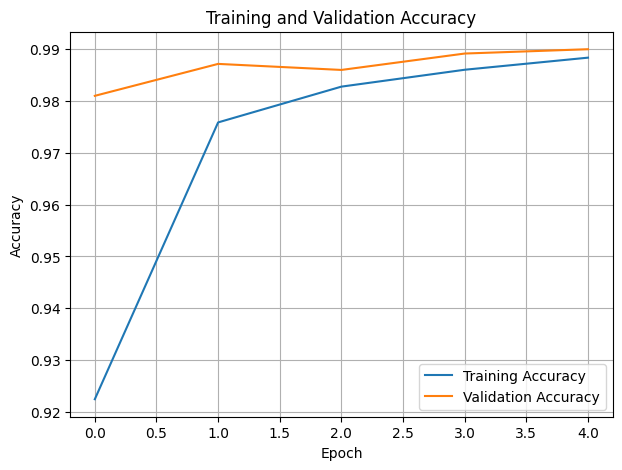

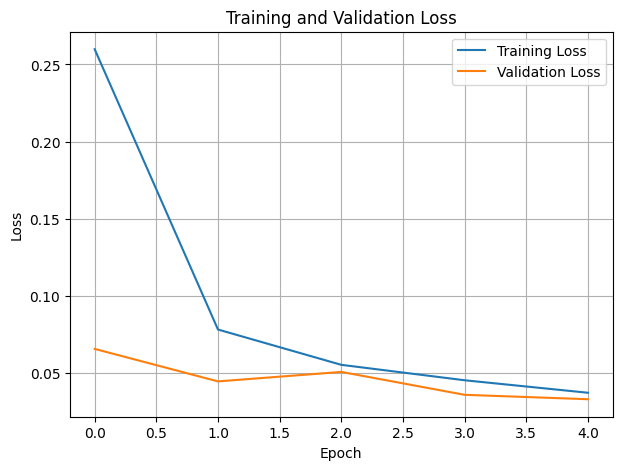

<Figure size 800x700 with 0 Axes>

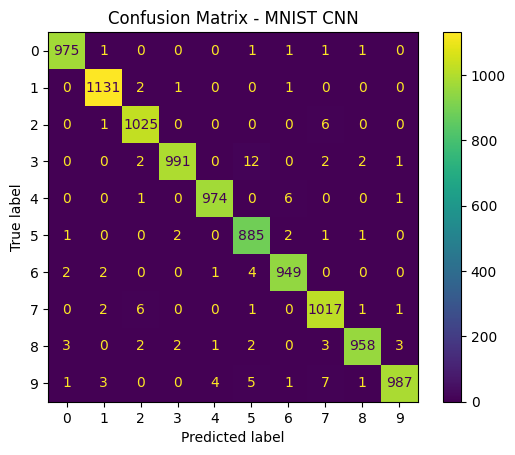

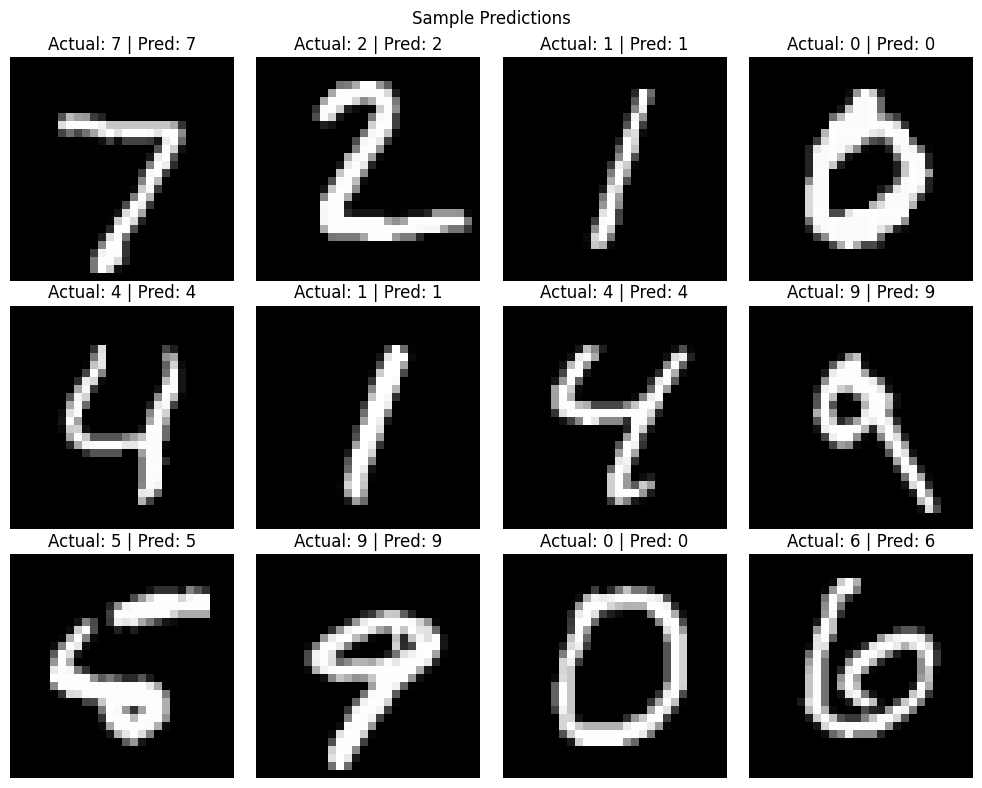


✅ DEEP LEARNING MINI PROJECT COMPLETED!
✅ Handwritten Digit Classification using CNN
✅ Dataset: MNIST
✅ Model: Convolutional Neural Network
✅ Optimizer: Adam
✅ Epochs: 5
✅ Test Accuracy: 98.92 %


In [5]:
# DEEP LEARNING MINI PROJECT
# Handwritten Digit Classification using CNN
# Dataset: MNIST

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow Version:", tf.__version__)

# 1. Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("\nDataset Loaded Successfully!")
print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)

# 2. Preprocessing
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# 3. Display Sample Images
plt.figure(figsize=(8, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title("Digit: " + str(y_train[i]))
    plt.axis("off")

plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

# 4. Build CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(10, activation="softmax")
])

# 5. Compile Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nCNN Model:")
model.summary()

# 6. Train Model
history = model.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=1
)

# 7. Evaluate Model
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\n==============================")
print("FINAL RESULTS")
print("==============================")
print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")

# ------------------------------------------------------------
# 8. Accuracy Graph
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 9. Loss Graph
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 10. Predictions
# ------------------------------------------------------------
predictions = model.predict(x_test, verbose=0)
y_pred = np.argmax(predictions, axis=1)

# ------------------------------------------------------------
# 11. Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot()
plt.title("Confusion Matrix - MNIST CNN")
plt.show()

# ------------------------------------------------------------
# 12. Display Predictions
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i].squeeze(), cmap="gray")

    actual = y_test[i]
    predicted = y_pred[i]

    plt.title(
        f"Actual: {actual} | Pred: {predicted}"
    )

    plt.axis("off")

plt.suptitle("Sample Predictions")
plt.tight_layout()
plt.show()

# 13. Final Message
print("\n✅ DEEP LEARNING MINI PROJECT COMPLETED!")
print("✅ Handwritten Digit Classification using CNN")
print("✅ Dataset: MNIST")
print("✅ Model: Convolutional Neural Network")
print("✅ Optimizer: Adam")
print("✅ Epochs: 5")
print("✅ Test Accuracy:", round(test_accuracy * 100, 2), "%")